
# STEP 1: Setting up the environment and required libraries
# installing required libraries, import them, and set basic  plotting defaults.






In [11]:
!pip -q install statsmodels scikit-learn xgboost

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# statsmodels (time series)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ML model
from xgboost import XGBRegressor

# plotting style
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

# reproducibility
np.random.seed(42)

print("The necessary Python libraries for data analysis, visualization, and time-series modelling have been successfully loaded.")
print("These libraries will support the processing and forecasting of UK trade data in the following steps.")


The necessary Python libraries for data analysis, visualization, and time-series modelling have been successfully loaded.
These libraries will support the processing and forecasting of UK trade data in the following steps.


# STEP 2: Loading the IMF trade dataset
# What we do here:
# 1) Upload the CSV into Colab
# 2) Read only the header first
# 3) Detect monthly columns like 2020-M01 (because IMF file is wide format)
# 4) Load only meta columns + monthly columns


In [12]:
from google.colab import files

# 2A) Upload file
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print("Uploaded file:", DATA_PATH)

# 2B) Read header only (fast)
header = pd.read_csv(DATA_PATH, nrows=0)
all_cols = header.columns.tolist()
print("Total columns in file:", len(all_cols))

# 2C) Detect monthly columns (e.g. 2020-M01)
monthly_pattern = re.compile(r"^\d{4}-M(0[1-9]|1[0-2])$")
MONTHLY_COLS = [c for c in all_cols if monthly_pattern.match(c)]

print("Monthly columns found:", len(MONTHLY_COLS))
print("Monthly columns example:", MONTHLY_COLS[:5], "...", MONTHLY_COLS[-5:])

if len(MONTHLY_COLS) == 0:
    raise ValueError("No monthly columns detected. Check if your file is in a different format.")

# 2D) Load only useful columns
META_COLS = ["SERIES_CODE", "COUNTRY", "INDICATOR", "FREQUENCY", "UNIT", "TR_DIRECTION", "TRADE_FLOW"]
META_COLS = [c for c in META_COLS if c in all_cols]

USECOLS = META_COLS + MONTHLY_COLS
df = pd.read_csv(DATA_PATH, usecols=USECOLS, low_memory=False)

print("Dataframe shape:", df.shape)
print("Meta columns kept:", META_COLS)

df.head(3)


Saving dataset_2026-01-24T11_01_30.305742485Z_DEFAULT_INTEGRATION_IMF.STA_ITG_4.0.0 (1).csv to dataset_2026-01-24T11_01_30.305742485Z_DEFAULT_INTEGRATION_IMF.STA_ITG_4.0.0 (1) (1).csv
Uploaded file: dataset_2026-01-24T11_01_30.305742485Z_DEFAULT_INTEGRATION_IMF.STA_ITG_4.0.0 (1) (1).csv
Total columns in file: 1368
Monthly columns found: 936
Monthly columns example: ['1948-M01', '1948-M02', '1948-M03', '1948-M04', '1948-M05'] ... ['2025-M08', '2025-M09', '2025-M10', '2025-M11', '2025-M12']
Dataframe shape: (5488, 943)
Meta columns kept: ['SERIES_CODE', 'COUNTRY', 'INDICATOR', 'FREQUENCY', 'UNIT', 'TR_DIRECTION', 'TRADE_FLOW']


,SERIES_CODE,COUNTRY,INDICATOR,FREQUENCY,TR_DIRECTION,TRADE_FLOW,UNIT,1948-M01,1948-M02,1948-M03,...,2025-M03,2025-M04,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12
0,SLB.XG_PD.FOB_IX.Q,Solomon Islands,"Exports of goods, Price deflator",Quarterly,Exports,Exports of goods,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PHL.XG_PD.FOB_IX.Q,Philippines,"Exports of goods, Price deflator",Quarterly,Exports,Exports of goods,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COL.MPI.CIF_IX.Q,Colombia,Import price index,Quarterly,Imports,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#STEP 3: Constructing the UK monthly trade time series (Exports and Imports)

# Why we do this:
# - IMF file is wide: each month is a separate column (e.g., 2020-M01)
# - Models need a proper datetime-indexed time series
# - We extract the correct UK export/import series and convert wide -> time series

In [13]:
# 3A) Filter UK
UK_NAME = "United Kingdom"
df_uk = df[df["COUNTRY"].astype(str).str.strip().eq(UK_NAME)].copy()
print("UK rows:", df_uk.shape[0])

# 3B) Select the correct series codes (these are present in your dataset)
EXPORT_CODE = "GBR.XG.FOB_USD.M"  # exports of goods, USD, monthly, FOB
IMPORT_CODE = "GBR.MG.CIF_USD.M"  # imports of goods, USD, monthly, CIF

exp_rows = df_uk[df_uk["SERIES_CODE"] == EXPORT_CODE]
imp_rows = df_uk[df_uk["SERIES_CODE"] == IMPORT_CODE]

# If anything doesn't match, show candidates to help correct selection
if exp_rows.empty or imp_rows.empty:
    print("Could not find one or both series codes in the UK subset.")
    print("Here are likely candidates (UK, monthly, USD):")
    candidates = df_uk[df_uk["SERIES_CODE"].astype(str).str.contains(r"\.M$") &
                       df_uk["SERIES_CODE"].astype(str).str.contains("USD")]
    display(candidates[["SERIES_CODE", "INDICATOR", "TR_DIRECTION", "TRADE_FLOW", "VALUATION"]].drop_duplicates().sort_values("SERIES_CODE"))
    raise ValueError("Update EXPORT_CODE / IMPORT_CODE based on the candidates above and re-run Step 3.")

# Your dataset has exactly one row each, so take the first
exp_row = exp_rows.iloc[0]
imp_row = imp_rows.iloc[0]

# Show metadata for transparency (good for report/viva)
meta_show = [c for c in ["SERIES_CODE","FREQUENCY","INDICATOR","TR_DIRECTION","TRADE_FLOW","VALUATION","OBS_MEASURE"] if c in df_uk.columns]
print("\nSelected series metadata:")
display(pd.DataFrame([exp_row[meta_show], imp_row[meta_show]]))

# 3C) Build datetime index for MONTHLY_COLS
# Convert 'YYYY-M01' -> month-end Timestamp (YYYY-MM-last_day)
month_index = (pd.to_datetime([c.replace("-M", "-") + "-01" for c in MONTHLY_COLS]) + pd.offsets.MonthEnd(0))

# 3D) Convert a wide row to a clean monthly series
def wide_row_to_series(row, name):
    values = pd.to_numeric(row[MONTHLY_COLS], errors="coerce")
    s = pd.Series(values.values, index=month_index, name=name)

    # drop empty leading/trailing months (your file has lots of blank early history)
    s = s.dropna()

    # enforce regular monthly frequency inside the valid range
    s = s.asfreq("M")

    # only fill if there are missing months inside the range
    if s.isna().any():
        s = s.interpolate(method="time")

    return s

exports = wide_row_to_series(exp_row, "exports_usd")
imports = wide_row_to_series(imp_row, "imports_usd")

# 3E) Combine + basic checks
trade = pd.concat([exports, imports], axis=1)
trade["trade_balance_usd"] = trade["exports_usd"] - trade["imports_usd"]

print("\nExports range:", exports.index.min(), "to", exports.index.max(), "| length:", len(exports), "| missing:", exports.isna().sum())
print("Imports range:", imports.index.min(), "to", imports.index.max(), "| length:", len(imports), "| missing:", imports.isna().sum())

# sanity checks (should be non-negative for total trade values)
print("\nAny negative exports?", (exports < 0).any())
print("Any negative imports?", (imports < 0).any())

trade.head()


UK rows: 56

Selected series metadata:


,SERIES_CODE,FREQUENCY,INDICATOR,TR_DIRECTION,TRADE_FLOW
5290,GBR.XG.FOB_USD.M,Monthly,Exports of goods,Exports,Exports of goods
5298,GBR.MG.CIF_USD.M,Monthly,Imports of goods,Imports,Imports of goods



Exports range: 2006-01-31 00:00:00 to 2025-10-31 00:00:00 | length: 238 | missing: 0
Imports range: 2006-01-31 00:00:00 to 2025-10-31 00:00:00 | length: 238 | missing: 0

Any negative exports? False
Any negative imports? False


/tmp/ipykernel_191/3672505952.py:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s = s.asfreq("M")
/tmp/ipykernel_191/3672505952.py:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s = s.asfreq("M")


,exports_usd,imports_usd,trade_balance_usd
2006-01-31,32.605,48.081,-15.476
2006-02-28,36.438,49.356,-12.918
2006-03-31,45.331,57.165,-11.834
2006-04-30,40.218,51.643,-11.425
2006-05-31,45.836,59.155,-13.319


# STEP 4:  Data cleaning and initial exploratory analysis(EDA)

# Goal:
# 1) Quick data-quality checks on the final time series (exports/imports)
# 2) Basic plots for report: imports vs exports, trade balance
# 3) Seasonality view (month-of-year)
# 4) Simple shock view (largest monthly % changes)

Exports: missing values = 0 | length = 238
Imports: missing values = 0 | length = 238

Exports summary:


,exports_usd
count,238.000000
mean,39.467172
std,5.556226
min,24.906000
25%,35.934500
50%,39.354000
75%,43.158250
max,56.228000



Imports summary:


,imports_usd
count,238.000000
mean,57.142605
std,8.744735
min,36.317000
25%,51.647250
50%,55.717500
75%,62.098500
max,85.377000



Index frequency check (first 5 dates):


DatetimeIndex(['2006-01-31', '2006-02-28', '2006-03-31', '2006-04-30',
               '2006-05-31'],
              dtype='datetime64[ns]', freq='ME')

Monthly freq set? (exports): ME


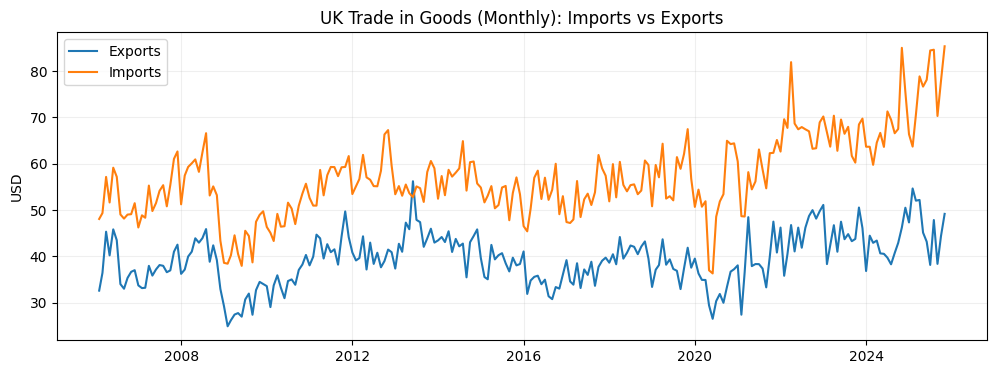

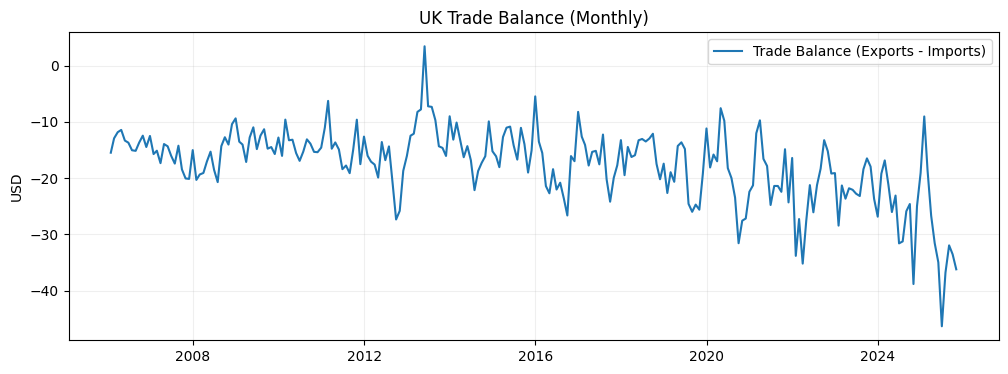

<Figure size 1200x400 with 0 Axes>

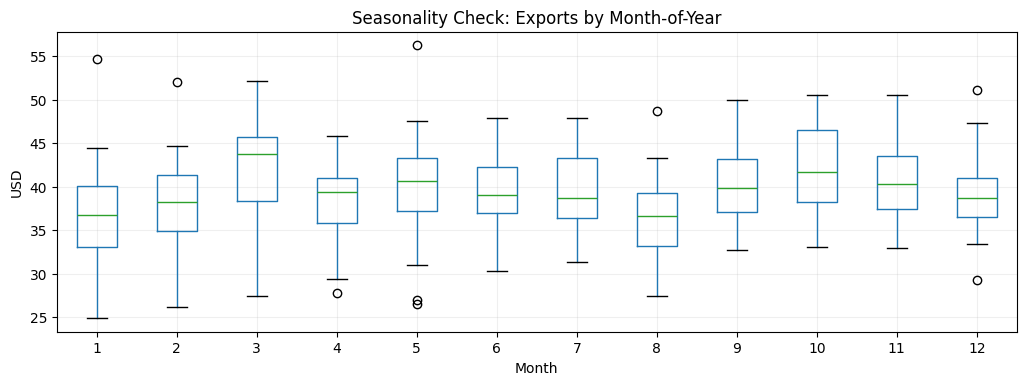

<Figure size 1200x400 with 0 Axes>

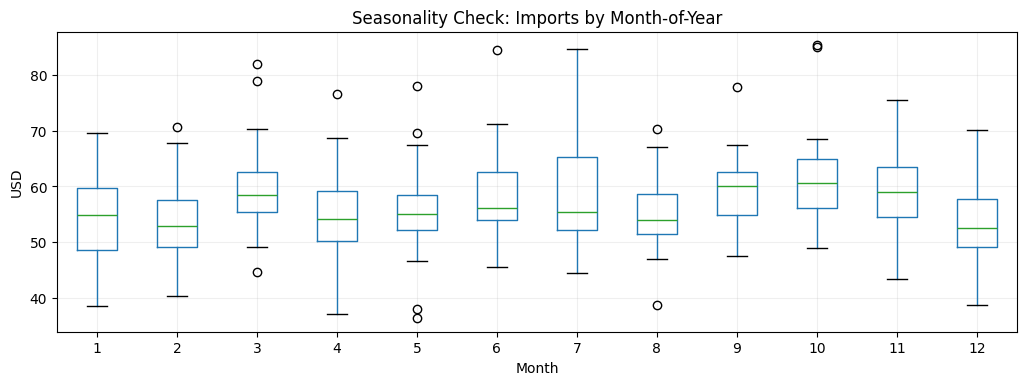


Top 10 export shocks (by absolute monthly % change):


,exports_usd
2021-02-28,33.476833
2021-03-31,32.485104
2021-01-31,27.989702
2025-07-31,25.411469
2023-01-31,24.993153
2006-03-31,24.405840
2013-05-31,22.591898
2022-01-31,22.511413
2016-01-31,22.328277
2021-04-30,21.810980



Top 10 import shocks (by absolute monthly % change):


,imports_usd
2020-06-30,33.714239
2020-04-30,28.735455
2024-10-31,25.954560
2009-09-30,22.636488
2020-09-30,21.600629
2022-03-31,20.968337
2008-08-31,20.198790
2009-06-30,19.978393
2021-03-31,19.709531
2021-01-31,19.507961


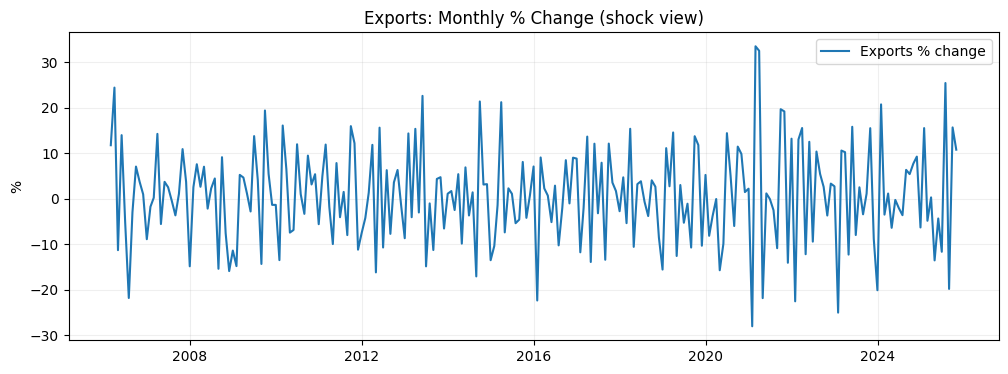

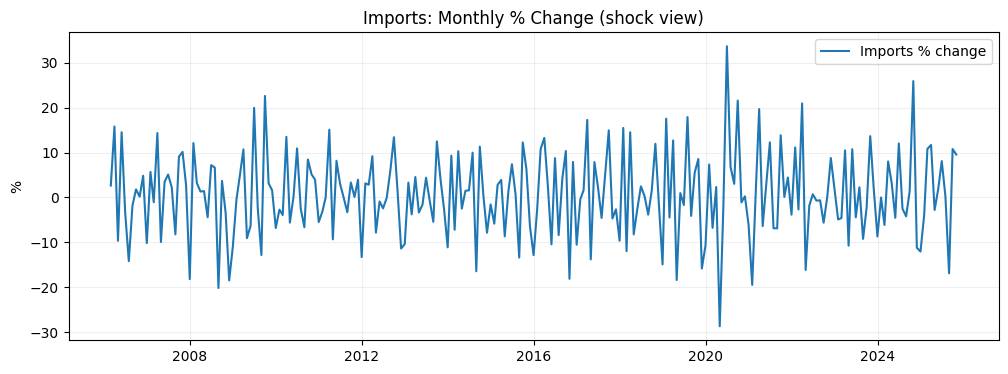

Top shocks (robust method) — Exports:


,series,value,pct_change_%,robust_z,abs_robust_z
2021-02-28,exports,36.586,33.476833,3.248792,3.248792
2021-03-31,exports,48.471,32.485104,3.149215,3.149215
2021-01-31,exports,27.410,-27.989702,-2.922869,2.922869
2023-01-31,exports,38.339,-24.993153,-2.621995,2.621995
2025-07-31,exports,47.852,25.411469,2.438974,2.438974
2022-01-31,exports,35.816,-22.511413,-2.372812,2.372812
2016-01-31,exports,31.899,-22.328277,-2.354424,2.354424
2006-03-31,exports,45.331,24.405840,2.338002,2.338002
2021-04-30,exports,37.899,-21.810980,-2.302483,2.302483
2006-07-31,exports,34.022,-21.779515,-2.299324,2.299324


Top shocks (robust method) — Imports:


,series,value,pct_change_%,robust_z,abs_robust_z
2020-06-30,imports,48.561,33.714239,3.848300,3.848300
2020-04-30,imports,36.992,-28.735455,-3.332371,3.332371
2024-10-31,imports,85.042,25.954560,2.956066,2.956066
2009-09-30,imports,47.464,22.636488,2.574544,2.574544
2020-09-30,imports,64.970,21.600629,2.455437,2.455437
2022-03-31,imports,81.950,20.968337,2.382734,2.382734
2008-08-31,imports,53.150,-20.198790,-2.350798,2.350798
2021-01-31,imports,48.684,-19.507961,-2.271364,2.271364
2009-06-30,imports,45.533,19.978393,2.268907,2.268907
2021-03-31,imports,58.192,19.709531,2.237992,2.237992


In [14]:
# 4A) Data quality checks
print("Exports: missing values =", exports.isna().sum(), "| length =", len(exports))
print("Imports: missing values =", imports.isna().sum(), "| length =", len(imports))

print("\nExports summary:")
display(exports.describe())

print("\nImports summary:")
display(imports.describe())

# Check if the index is monthly and continuous
print("\nIndex frequency check (first 5 dates):")
display(exports.index[:5])
print("Monthly freq set? (exports):", exports.index.freqstr)

# 4B) Core EDA plots: Imports vs Exports
plt.figure(figsize=(12,4))
plt.plot(exports.index, exports.values, label="Exports")
plt.plot(imports.index, imports.values, label="Imports")
plt.title("UK Trade in Goods (Monthly): Imports vs Exports")
plt.ylabel("USD")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Trade balance (exports - imports)
trade_balance = exports - imports

plt.figure(figsize=(12,4))
plt.plot(trade_balance.index, trade_balance.values, label="Trade Balance (Exports - Imports)")
plt.title("UK Trade Balance (Monthly)")
plt.ylabel("USD")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 4C) Seasonality view: month-of-year patterns
# This is very useful in presentation because it clearly shows "seasonality" in one figure.

def month_of_year_view(series, title):
    temp = pd.DataFrame({"value": series.values, "month": series.index.month})
    plt.figure(figsize=(12,4))
    temp.boxplot(column="value", by="month")
    plt.title(title)
    plt.suptitle("")  # removes the automatic pandas title
    plt.xlabel("Month")
    plt.ylabel("USD")
    plt.grid(True, alpha=0.2)
    plt.show()

month_of_year_view(exports, "Seasonality Check: Exports by Month-of-Year")
month_of_year_view(imports, "Seasonality Check: Imports by Month-of-Year")

# 4D) Quick shock view: biggest monthly % changes
# We keep it simple here: percent change shows sudden jumps/drops clearly.
# Later we can do a robust shock table (MAD z-score) if you want.

exp_pct = exports.pct_change() * 100
imp_pct = imports.pct_change() * 100

print("\nTop 10 export shocks (by absolute monthly % change):")
display(exp_pct.abs().sort_values(ascending=False).head(10))

print("\nTop 10 import shocks (by absolute monthly % change):")
display(imp_pct.abs().sort_values(ascending=False).head(10))

# Visualize monthly % change to see volatile periods
plt.figure(figsize=(12,4))
plt.plot(exp_pct.index, exp_pct.values, label="Exports % change")
plt.title("Exports: Monthly % Change (shock view)")
plt.ylabel("%")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(imp_pct.index, imp_pct.values, label="Imports % change")
plt.title("Imports: Monthly % Change (shock view)")
plt.ylabel("%")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


# STEP 4E (Improvement A): Robust shock detection (MAD z-score)
# Why do this?
# Monthly % change is useful, but it can overreact to extreme values.
# Robust z-score using MAD is less sensitive to outliers and gives a cleaner "shock ranking".

def robust_zscore(x):
    x = pd.Series(x).dropna()
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        # if MAD is zero, everything is basically the same; return zeros
        return pd.Series(np.zeros(len(x)), index=x.index)
    return 0.6745 * (x - med) / mad

def shock_table(series, name, top_n=10):
    pct = series.pct_change() * 100
    rz = robust_zscore(pct)
    out = pd.DataFrame({
        "series": name,
        "value": series,
        "pct_change_%": pct,
        "robust_z": rz
    }).dropna()
    out["abs_robust_z"] = out["robust_z"].abs()
    return out.sort_values("abs_robust_z", ascending=False).head(top_n)

shocks_exports = shock_table(exports, "exports", top_n=10)
shocks_imports = shock_table(imports, "imports", top_n=10)

print("Top shocks (robust method) — Exports:")
display(shocks_exports)

print("Top shocks (robust method) — Imports:")
display(shocks_imports)




# STEP 5: Time-series decomposition and stationarity analysis + ACF/PACF

# Why this step matters:
# - Decomposition gives clear trend/seasonality/residual story for report & presentation
# - ADF stationarity test supports differencing choices for SARIMA
# - ACF/PACF plots support AR/MA ideas (even if we later do small grid search)


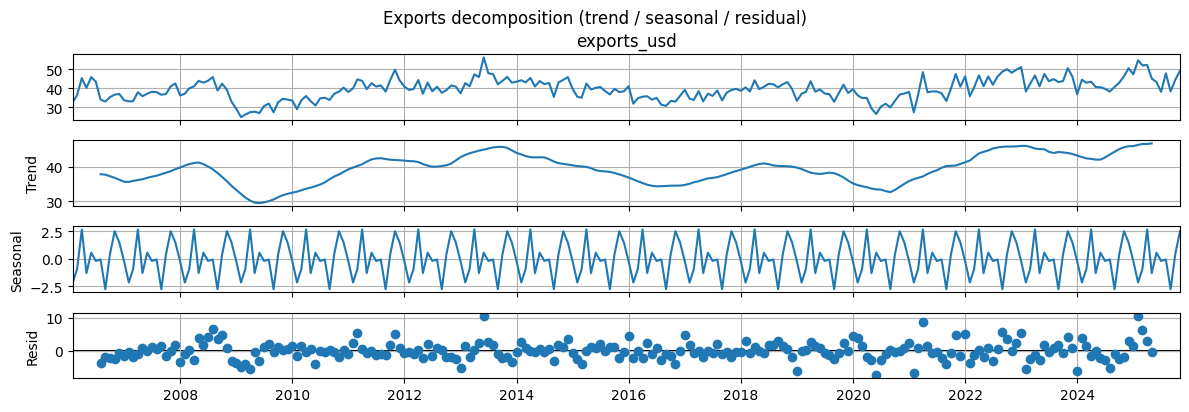

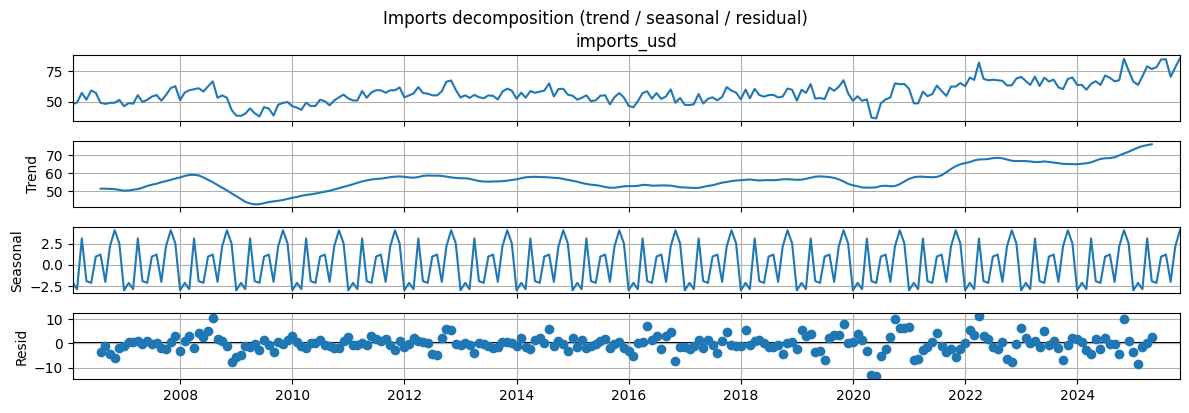

ADF test results:

Exports (level)
  ADF statistic: -2.4246
  p-value      : 0.1349
  lags used    : 12
  nobs         : 225
  critical vals: {'1%': np.float64(-3.4598), '5%': np.float64(-2.8745), '10%': np.float64(-2.5737)}

Exports (1st difference)
  ADF statistic: -5.2091
  p-value      : 0.0
  lags used    : 11
  nobs         : 225
  critical vals: {'1%': np.float64(-3.4598), '5%': np.float64(-2.8745), '10%': np.float64(-2.5737)}

Imports (level)
  ADF statistic: -1.2005
  p-value      : 0.6734
  lags used    : 12
  nobs         : 225
  critical vals: {'1%': np.float64(-3.4598), '5%': np.float64(-2.8745), '10%': np.float64(-2.5737)}

Imports (1st difference)
  ADF statistic: -5.204
  p-value      : 0.0
  lags used    : 14
  nobs         : 222
  critical vals: {'1%': np.float64(-3.4602), '5%': np.float64(-2.8746), '10%': np.float64(-2.5738)}



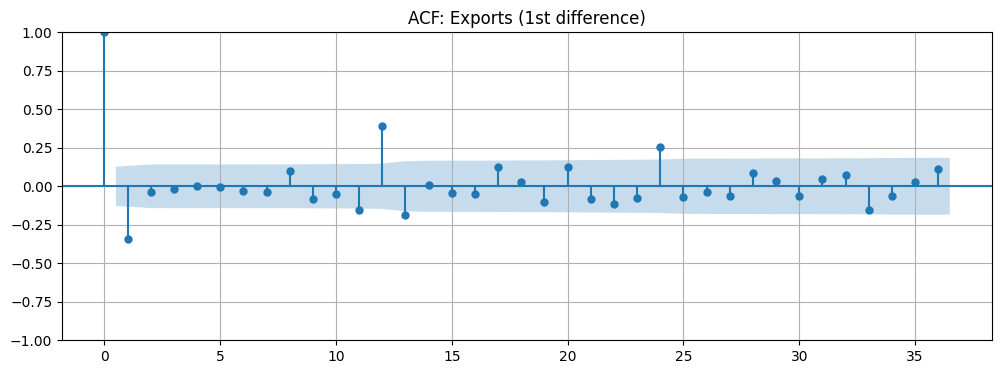

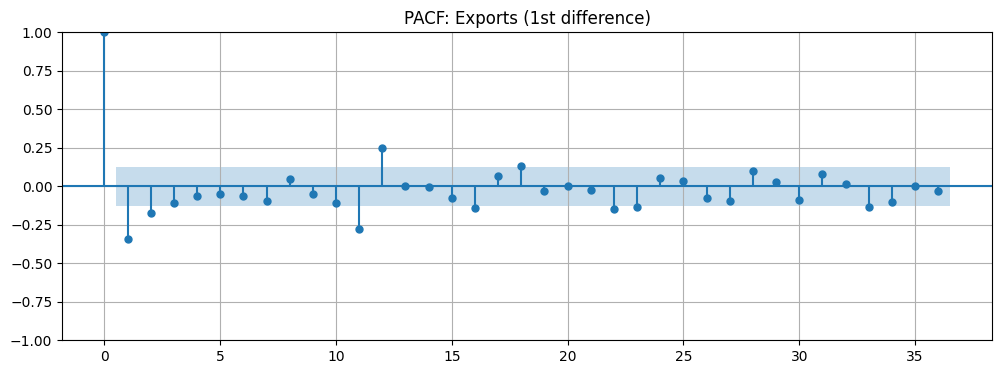

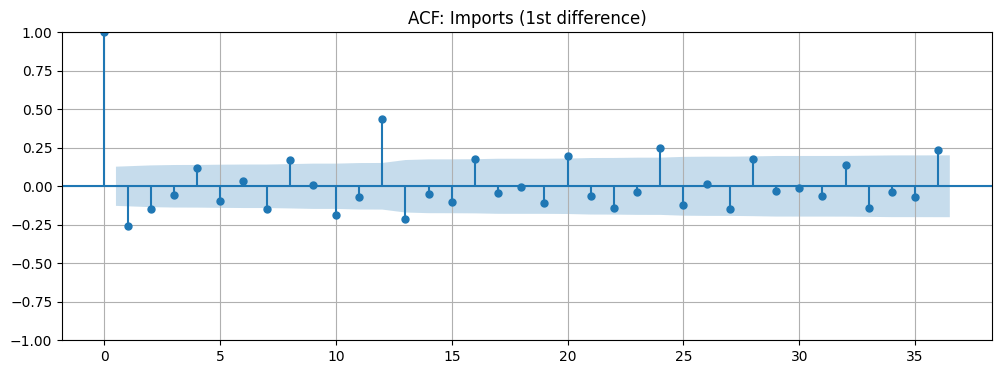

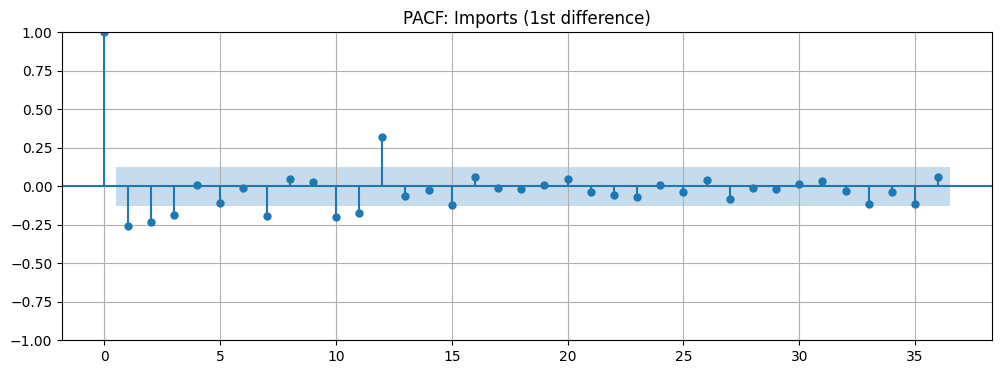

In [15]:
# 5A) Seasonal decomposition (Exports)
# We use period=12 because data is monthly and seasonality is typically yearly.

decomp_exp = seasonal_decompose(exports, model="additive", period=12)
decomp_exp.plot()
plt.suptitle("Exports decomposition (trend / seasonal / residual)", y=1.02)
plt.show()

# 5B) Seasonal decomposition (Imports)
decomp_imp = seasonal_decompose(imports, model="additive", period=12)
decomp_imp.plot()
plt.suptitle("Imports decomposition (trend / seasonal / residual)", y=1.02)
plt.show()


# 5C) Stationarity check using ADF test
# SARIMA needs the series to be stationary after differencing.
# We'll test both: (1) level series and (2) first-differenced series.
# Interpretation:
# - p-value < 0.05 suggests stationarity (reject unit root)

def adf_report(series, name):
    series = series.dropna()
    stat, pval, lags, nobs, crit, icbest = adfuller(series, autolag="AIC")
    print(name)
    print("  ADF statistic:", round(stat, 4))
    print("  p-value      :", round(pval, 4))
    print("  lags used    :", lags)
    print("  nobs         :", nobs)
    print("  critical vals:", {k: round(v, 4) for k, v in crit.items()})
    print()

print("ADF test results:\n")

adf_report(exports, "Exports (level)")
adf_report(exports.diff(), "Exports (1st difference)")

adf_report(imports, "Imports (level)")
adf_report(imports.diff(), "Imports (1st difference)")


# 5D) ACF/PACF plots (use differenced series)
# We look at ACF/PACF of the differenced series because that is closer to stationary.
# This helps justify SARIMA components:
# - ACF shows correlation with lagged values (MA behavior)
# - PACF shows partial correlation (AR behavior)

exp_diff = exports.diff().dropna()
imp_diff = imports.diff().dropna()

# Exports ACF
plot_acf(exp_diff, lags=36)
plt.title("ACF: Exports (1st difference)")
plt.show()

# Exports PACF
plot_pacf(exp_diff, lags=36, method="ywm")
plt.title("PACF: Exports (1st difference)")
plt.show()

# Imports ACF
plot_acf(imp_diff, lags=36)
plt.title("ACF: Imports (1st difference)")
plt.show()

# Imports PACF
plot_pacf(imp_diff, lags=36, method="ywm")
plt.title("PACF: Imports (1st difference)")
plt.show()


# STEP 6: Model evaluation setup using rolling backtesting

# Fixes vs old Step 6:
# - fixes MAE typo risk
# - ensures we only score FULL 3-month horizons (no partial windows)
# - automatically adjusts number of windows if data is shorter than requested
# - refuses NaN forecasts (so we don't accidentally evaluate broken outputs)
# - adds MASE + Bias (stronger reporting, optional to use)


In [16]:
HORIZON = 3          # next quarter = next 3 months
WINDOWS = 8          # number of rolling windows (will be reduced if not feasible)
MIN_TRAIN = 60       # minimum training length in months

# 6A) Metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom[denom == 0] = 1e-9
    return float(np.mean(np.abs(y_pred - y_true) / denom) * 100.0)

def bias(y_true, y_pred):
    # mean error (positive means over-forecast on average)
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))

def mase(y_true, y_pred, train, seasonality=12):
    # Mean Absolute Scaled Error
    # scale = MAE of seasonal naive one-step errors on the training set
    # If scale is too small, MASE becomes unstable; we guard with eps.
    train = pd.Series(train).dropna()
    naive_err = (train[seasonality:] - train.shift(seasonality)[seasonality:]).abs().dropna()
    scale = float(naive_err.mean()) if len(naive_err) > 0 else np.nan
    eps = 1e-9
    if not np.isfinite(scale) or scale < eps:
        return np.nan
    return float(mae(y_true, y_pred) / scale)

def score_all(y_true, y_pred, train_for_mase=None):
    out = {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
        "Bias": bias(y_true, y_pred),
    }
    if train_for_mase is not None:
        out["MASE"] = mase(y_true, y_pred, train_for_mase, seasonality=12)
    else:
        out["MASE"] = np.nan
    return out

# 6B) Utility: quarter total from 3 months (sum)
def quarterly_sum_from_3months(y_3m):
    return float(np.sum(np.array(y_3m, dtype=float)))

# 6C) Rolling backtest framework
def rolling_backtest(series, forecast_fn, model_name, horizon=HORIZON, windows=WINDOWS, min_train=MIN_TRAIN):
    # basic checks
    series = series.dropna().copy()
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DatetimeIndex.")
    series = series.sort_index()

    n = len(series)
    if n < (min_train + horizon):
        raise ValueError(f"Not enough data. Need at least {min_train + horizon} points, got {n}.")

    # compute max feasible number of FULL windows
    max_windows = (n - min_train) // horizon
    windows_eff = int(min(windows, max_windows))

    if windows_eff < 1:
        raise ValueError("Backtest cannot run even 1 full window with current MIN_TRAIN/HORIZON.")

    # we evaluate on the last windows_eff * horizon months
    total_test = windows_eff * horizon
    start_test = n - total_test

    results = []

    for w in range(windows_eff):
        train_end = start_test + w * horizon
        train = series.iloc[:train_end]
        test = series.iloc[train_end:train_end + horizon]

        # enforce full horizon
        if len(test) < horizon:
            break

        # forecast next horizon months
        pred = forecast_fn(train, horizon=horizon)

        # enforce correct index alignment
        pred = pred.reindex(test.index)

        # no-compromise: refuse NaN forecasts
        if pred.isna().any():
            raise ValueError(f"{model_name}: forecast produced NaNs after alignment in window {w+1}.")

        # metrics
        m = score_all(test.values, pred.values, train_for_mase=train.values)

        # quarter totals
        q_true = quarterly_sum_from_3months(test.values)
        q_pred = quarterly_sum_from_3months(pred.values)
        q_err = abs(q_true - q_pred)

        results.append({
            "model": model_name,
            "window": w + 1,
            "train_end": train.index[-1],
            "test_start": test.index[0],
            "test_end": test.index[-1],
            "MAE": m["MAE"],
            "RMSE": m["RMSE"],
            "sMAPE_%": m["sMAPE_%"],
            "Bias": m["Bias"],
            "MASE": m["MASE"],
            "Quarter_true_sum": q_true,
            "Quarter_pred_sum": q_pred,
            "Quarter_abs_error": q_err
        })

    return pd.DataFrame(results)
print("EDA has been conducted to better understand the behaviour of the trade data.")
print("Visualisations help identify patterns, trends, and possible seasonal movements in the time series.")
print("HORIZON =", HORIZON, "| WINDOWS =", WINDOWS, "| MIN_TRAIN =", MIN_TRAIN)


EDA has been conducted to better understand the behaviour of the trade data.
Visualisations help identify patterns, trends, and possible seasonal movements in the time series.
HORIZON = 3 | WINDOWS = 8 | MIN_TRAIN = 60


# STEP 7: Developing forecasting models for trade prediction

# Goal: define forecasting functions with the SAME signature:
#   forecast_fn(train_series, horizon=3) -> pd.Series forecast (next 3 months)
# So we can compare models fairly using the Step 6 backtest engine.

In [17]:
# 7A) (Safety) metrics helpers (in case Step 6 had a typo)
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom[denom == 0] = 1e-9
    return float(np.mean(np.abs(y_pred - y_true) / denom) * 100.0)

def score(y_true, y_pred):
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "sMAPE_%": smape(y_true, y_pred)}

# helper: future monthly index (month-end)
def make_future_index(train, horizon):
    return pd.date_range(train.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="M")


# 7B) Model 1: Seasonal Naïve (baseline)
# Forecast each month as the same month last year.
def forecast_seasonal_naive(train, horizon=3):
    future_idx = make_future_index(train, horizon)
    preds = []
    for dt in future_idx:
        prev_year = dt - pd.DateOffset(years=1)
        if prev_year in train.index:
            preds.append(float(train.loc[prev_year]))
        else:
            preds.append(np.nan)
    fc = pd.Series(preds, index=future_idx, name="SeasonalNaive")
    # if any NaNs (rare), fill with nearest available
    fc = fc.fillna(method="ffill").fillna(method="bfill")
    return fc


# 7C) Model 2: ETS (Exponential Smoothing)
# Strong for monthly macro series with trend + seasonality.
def forecast_ets(train, horizon=3):
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    )
    fit = model.fit(optimized=True)
    fc = fit.forecast(horizon)
    fc.name = "ETS"
    return fc


# 7D) Model 3: SARIMA (strong but practical)
# We do a small candidate search using AIC to avoid heavy runtime.
# This is stronger than a single fixed SARIMA, but still feasible in backtesting.
SARIMA_CANDIDATES = [
    ((1,1,1), (1,1,1,12)),
    ((2,1,1), (1,1,1,12)),
    ((1,1,2), (1,1,1,12)),
    ((0,1,1), (1,1,1,12)),
    ((1,1,1), (0,1,1,12)),
    ((1,1,1), (1,1,0,12)),
    ((2,1,0), (1,1,1,12)),
    ((0,1,2), (1,1,1,12)),
]

def fit_best_sarima(train):
    best_aic = np.inf
    best_fit = None
    best_cfg = None

    for order, seasonal_order in SARIMA_CANDIDATES:
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_fit = fit
                best_cfg = (order, seasonal_order)
        except Exception:
            continue

    if best_fit is None:
        raise RuntimeError("SARIMA fitting failed for all candidate configs.")
    return best_fit, best_cfg, best_aic

def forecast_sarima(train, horizon=3):
    fit, cfg, aic = fit_best_sarima(train)
    fc = fit.forecast(horizon)
    fc.name = f"SARIMA{cfg[0]}{cfg[1]}"
    return fc


# 7E) Model 4: XGBoost (lags + rolling + seasonality)
# We build a supervised learning dataset:
# - lag features: 1,2,3,6,12
# - rolling stats: mean/std over 3,6,12
# - month sin/cos for seasonality
# We use "direct" forecasting: separate model for h=1,2,3 (reduces error compounding).

def add_time_features(idx):
    m = idx.month
    return pd.DataFrame({
        "month_sin": np.sin(2*np.pi*m/12.0),
        "month_cos": np.cos(2*np.pi*m/12.0),
    }, index=idx)

def make_features(series):
    df_feat = pd.DataFrame({"y": series})
    for lag in [1,2,3,6,12]:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
    for w in [3,6,12]:
        df_feat[f"roll_mean_{w}"] = df_feat["y"].rolling(w).mean()
        df_feat[f"roll_std_{w}"]  = df_feat["y"].rolling(w).std()
    df_feat = pd.concat([df_feat, add_time_features(df_feat.index)], axis=1)
    return df_feat.dropna()

def train_xgb_direct(series, horizon):
    frame = make_features(series)
    frame[f"target_h{horizon}"] = frame["y"].shift(-horizon)
    frame = frame.dropna()

    X = frame.drop(columns=["y", f"target_h{horizon}"])
    y = frame[f"target_h{horizon}"]

    model = XGBRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model.fit(X, y)
    return model, X.columns

def forecast_xgb(train, horizon=3):
    future_idx = make_future_index(train, horizon)

    # train direct models for each step
    models = {}
    feat_cols = None
    for h in range(1, horizon+1):
        m, cols = train_xgb_direct(train, horizon=h)
        models[h] = m
        feat_cols = cols

    # last available feature row
    last_row = make_features(train).iloc[[-1]]
    X_last = last_row.drop(columns=["y"])[feat_cols]

    preds = [float(models[h].predict(X_last)[0]) for h in range(1, horizon+1)]
    return pd.Series(preds, index=future_idx, name="XGBoost")


# 7F) Quick smoke test (optional but useful)
# This confirms each model returns a 3-month forecast without crashing.
print("Smoke test on exports (next 3 months):")
display(forecast_seasonal_naive(exports, 3))
display(forecast_ets(exports, 3))
display(forecast_sarima(exports, 3))
display(forecast_xgb(exports, 3))

print("Seasonal decomposition has been performed on the trade time series.")
print("This process separates the data into three components: trend, seasonality, and residual variations.")
print("Understanding these components helps in building more accurate forecasting models.")

Smoke test on exports (next 3 months):


/tmp/ipykernel_191/2631148841.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return pd.date_range(train.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="M")
/tmp/ipykernel_191/2631148841.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fc = fc.fillna(method="ffill").fillna(method="bfill")


,SeasonalNaive
2025-11-30,50.512
2025-12-31,47.330
2026-01-31,54.674


,ETS
2025-11-30,46.950555
2025-12-31,45.221871
2026-01-31,43.203252


,"SARIMA(1, 1, 2)(1, 1, 1, 12)"
2025-11-30,46.970466
2025-12-31,45.472138
2026-01-31,43.582471


/tmp/ipykernel_191/2631148841.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return pd.date_range(train.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="M")


,XGBoost
2025-11-30,43.150162
2025-12-31,43.810970
2026-01-31,41.919872


Seasonal decomposition has been performed on the trade time series.
This process separates the data into three components: trend, seasonality, and residual variations.
Understanding these components helps in building more accurate forecasting models.


#STEP 8: Comparing model performance and selecting the best model
# Why this version is better:
# - runs models in a loop (cleaner, less repetition)
# - handles model failures gracefully (won't crash whole notebook)
# - reports mean + std of metrics (shows stability, not just average)
# - adds improvement vs baseline
# - ranking uses RMSE first, then quarterly error as tie-breaker


/tmp/ipykernel_191/2631148841.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return pd.date_range(train.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="M")
/tmp/ipykernel_191/2631148841.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fc = fc.fillna(method="ffill").fillna(method="bfill")
/tmp/ipykernel_191/2631148841.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return pd.date_range(train.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="M")
/tmp/ipykernel_191/2631148841.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fc = fc.fillna(method="ffill").fillna(method="bfill")
/tmp/ipykernel_191/2631148841.py:20: FutureWarning: 'M' is deprecated and will be removed in

Exports backtest sample:


,model,window,train_end,test_start,test_end,MAE,RMSE,sMAPE_%,Bias,MASE,Quarter_true_sum,Quarter_pred_sum,Quarter_abs_error,series
0,SeasonalNaive,1,2023-10-31,2023-11-30,2024-01-31,8.022667,9.215361,18.303029,3.933333,1.557645,127.408,139.208,11.800,exports
1,SeasonalNaive,2,2024-01-31,2024-02-29,2024-04-30,1.399667,1.948433,3.154650,1.047000,0.269553,126.996,130.137,3.141,exports
2,SeasonalNaive,3,2024-04-30,2024-05-31,2024-07-31,5.815000,5.959232,13.670402,5.815000,1.131799,118.561,136.006,17.445,exports
3,SeasonalNaive,4,2024-07-31,2024-08-31,2024-10-31,2.574000,2.939270,5.655170,2.574000,0.500052,129.877,137.599,7.722,exports
4,SeasonalNaive,5,2024-10-31,2024-11-30,2025-01-31,8.369333,8.824405,18.215846,-8.369333,1.637390,152.516,127.408,25.108,exports


Imports backtest sample:


,model,window,train_end,test_start,test_end,MAE,RMSE,sMAPE_%,Bias,MASE,Quarter_true_sum,Quarter_pred_sum,Quarter_abs_error,series
0,SeasonalNaive,1,2023-10-31,2023-11-30,2024-01-31,3.483000,4.199528,5.229036,2.933000,0.577886,197.118,205.917,8.799,imports
1,SeasonalNaive,2,2024-01-31,2024-02-29,2024-04-30,4.536667,4.626033,6.984877,1.956667,0.757385,191.004,196.874,5.870,imports
2,SeasonalNaive,3,2024-04-30,2024-05-31,2024-07-31,4.096667,4.498912,6.046435,-0.152000,0.686330,204.476,204.020,0.456,imports
3,SeasonalNaive,4,2024-07-31,2024-08-31,2024-10-31,9.571667,10.813069,13.523034,-9.571667,1.610761,219.155,190.440,28.715,imports
4,SeasonalNaive,5,2024-10-31,2024-11-30,2025-01-31,2.824000,3.662569,4.035129,-2.824000,0.471200,205.590,197.118,8.472,imports



Exports summary (mean + std, lower is better):


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,sMAPE_%_mean,sMAPE_%_std,Quarter_abs_error_mean,Quarter_abs_error_std,RMSE_mean_improve_vs_baseline_%,MAE_mean_improve_vs_baseline_%,sMAPE_%_mean_improve_vs_baseline_%,Quarter_abs_error_mean_improve_vs_baseline_%
model,,,,,,,,,,,,
XGBoost,4.092325,2.576812,4.587718,2.811488,9.277621,5.439237,9.747685,8.842342,17.654526,18.777561,18.078992,21.855984
ETS,4.284054,2.002286,5.012872,2.341819,9.632799,4.173801,12.267589,6.512587,10.023380,14.972214,14.942786,1.654727
SARIMA,4.294280,2.032953,5.063858,2.403242,9.650484,4.256137,12.137656,6.363930,9.108233,14.769248,14.786626,2.696357
SeasonalNaive,5.038417,2.750334,5.571305,2.891860,11.325082,6.062988,12.474000,8.401411,0.000000,0.000000,0.000000,0.000000



Imports summary (mean + std, lower is better):


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,sMAPE_%_mean,sMAPE_%_std,Quarter_abs_error_mean,Quarter_abs_error_std,RMSE_mean_improve_vs_baseline_%,MAE_mean_improve_vs_baseline_%,sMAPE_%_mean_improve_vs_baseline_%,Quarter_abs_error_mean_improve_vs_baseline_%
model,,,,,,,,,,,,
SARIMA,5.234530,2.365061,5.825280,2.625713,7.246150,3.157273,13.216180,8.905351,21.185121,22.031732,23.524554,24.427150
ETS,5.258515,2.414764,5.840352,2.694351,7.241072,3.241787,13.741711,8.809006,20.981205,21.674466,23.578149,21.422057
SeasonalNaive,6.713667,4.095184,7.391092,3.982200,9.475133,5.386905,17.488000,14.744543,0.000000,0.000000,0.000000,0.000000
XGBoost,7.047484,3.373195,8.221952,3.572649,9.821308,4.285901,15.855520,13.029001,-11.241375,-4.972202,-3.653513,9.334856



Best model (exports): XGBoost
Best model (imports): SARIMA


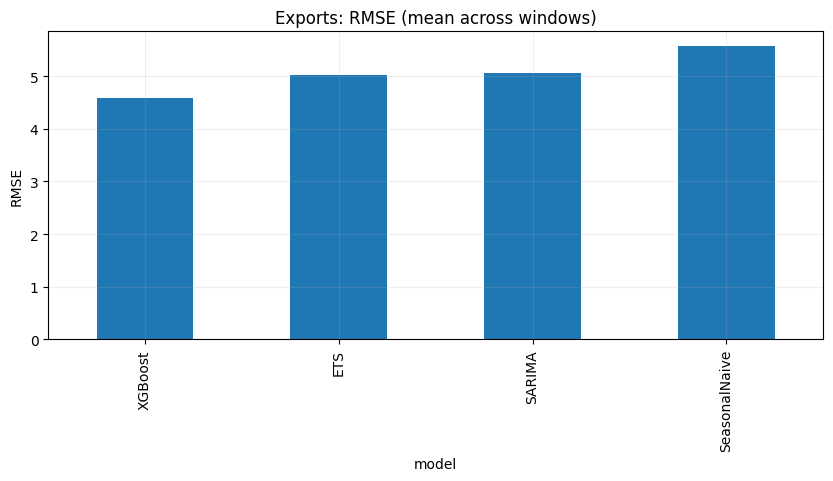

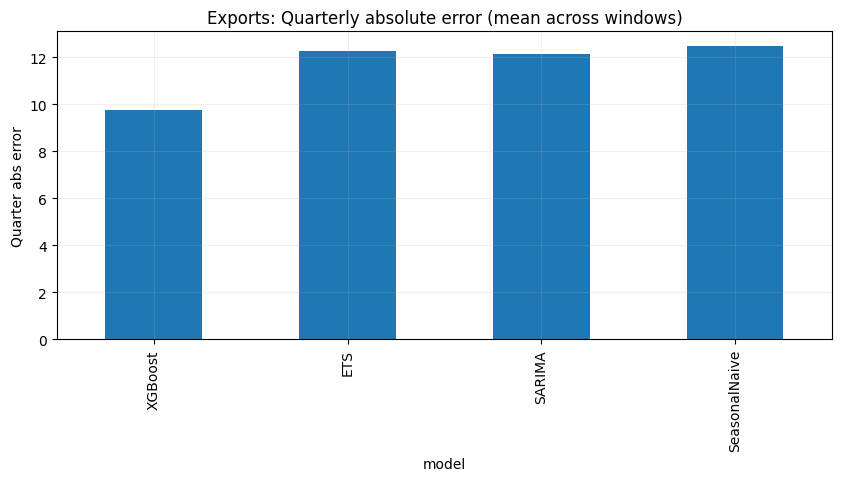

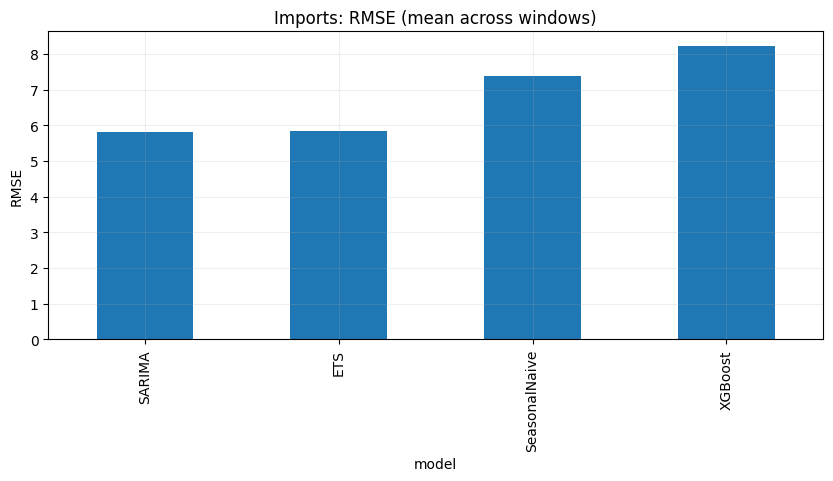

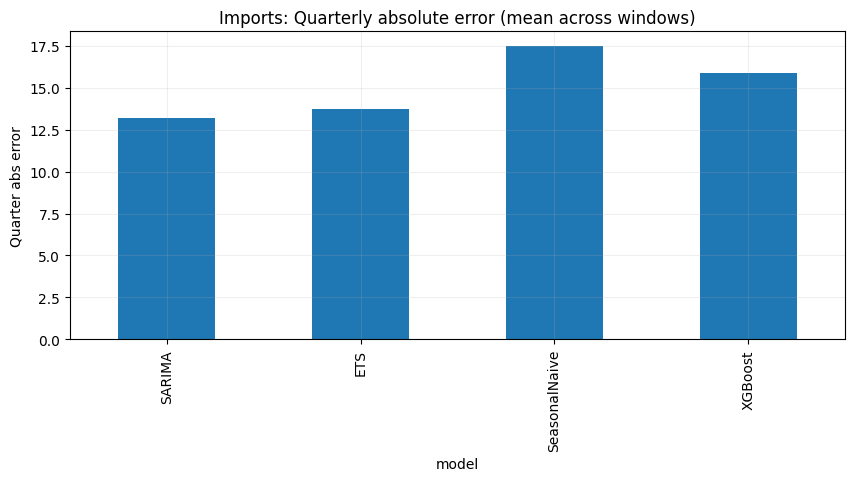

In [18]:
# Models to compare
MODELS = [
    ("SeasonalNaive", forecast_seasonal_naive),
    ("ETS",          forecast_ets),
    ("SARIMA",       forecast_sarima),
    ("XGBoost",      forecast_xgb),
]

def run_all_models_backtest(series, series_label):
    all_results = []
    failed = []

    for name, fn in MODELS:
        try:
            bt = rolling_backtest(series, fn, name, horizon=HORIZON, windows=WINDOWS, min_train=MIN_TRAIN)
            bt["series"] = series_label
            all_results.append(bt)
        except Exception as e:
            failed.append((series_label, name, str(e)))

    if failed:
        print("Some models failed during backtest:")
        for s, m, err in failed:
            print(f"  series={s} model={m} error={err[:200]}")

    if len(all_results) == 0:
        raise RuntimeError(f"All models failed for series: {series_label}")

    return pd.concat(all_results, ignore_index=True)

def summarize_backtest(bt_df):
    # mean + std gives you "average performance" + "stability across windows"
    agg = bt_df.groupby("model")[["MAE", "RMSE", "sMAPE_%", "Quarter_abs_error"]].agg(["mean", "std"])
    agg.columns = ["_".join(c) for c in agg.columns]  # flatten columns

    # improvement vs baseline (Seasonal Naive) in %
    baseline = "SeasonalNaive"
    if baseline in agg.index:
        for metric in ["RMSE_mean", "MAE_mean", "sMAPE_%_mean", "Quarter_abs_error_mean"]:
            agg[f"{metric}_improve_vs_baseline_%"] = (agg.loc[baseline, metric] - agg[metric]) / agg.loc[baseline, metric] * 100.0

    # ranking rule:
    # 1) lowest RMSE_mean wins
    # 2) tie-breaker: lowest Quarter_abs_error_mean
    # 3) next: lowest sMAPE_%_mean
    agg = agg.sort_values(["RMSE_mean", "Quarter_abs_error_mean", "sMAPE_%_mean"])

    return agg

# Run backtests
bt_exports_all = run_all_models_backtest(exports, "exports")
bt_imports_all = run_all_models_backtest(imports, "imports")

print("Exports backtest sample:")
display(bt_exports_all.head())

print("Imports backtest sample:")
display(bt_imports_all.head())

# Summaries
summary_exports = summarize_backtest(bt_exports_all)
summary_imports = summarize_backtest(bt_imports_all)

print("\nExports summary (mean + std, lower is better):")
display(summary_exports)

print("\nImports summary (mean + std, lower is better):")
display(summary_imports)

# Pick winners
best_model_exports = summary_exports.index[0]
best_model_imports = summary_imports.index[0]

print("\nBest model (exports):", best_model_exports)
print("Best model (imports):", best_model_imports)

# Quick charts (RMSE mean + Quarterly error mean)
plt.figure(figsize=(10,4))
summary_exports["RMSE_mean"].plot(kind="bar")
plt.title("Exports: RMSE (mean across windows)")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10,4))
summary_exports["Quarter_abs_error_mean"].plot(kind="bar")
plt.title("Exports: Quarterly absolute error (mean across windows)")
plt.ylabel("Quarter abs error")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10,4))
summary_imports["RMSE_mean"].plot(kind="bar")
plt.title("Imports: RMSE (mean across windows)")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10,4))
summary_imports["Quarter_abs_error_mean"].plot(kind="bar")
plt.title("Imports: Quarterly absolute error (mean across windows)")
plt.ylabel("Quarter abs error")
plt.grid(True, alpha=0.2)
plt.show()



#STEP 9: Generating the final trade forecasts
# Goal:
# 1) Use the best model (from Step 8) and train on the FULL series
# 2) Forecast next 3 months (quarter horizon)
# 3) Add uncertainty bands where possible (SARIMA exact, ETS bootstrap)
# 4) Compute "quarter total" = sum of next 3 months
# 5) Plot and save outputs for the report


Best model (exports): XGBoost
Best model (imports): SARIMA


/tmp/ipykernel_191/2631148841.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return pd.date_range(train.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="M")



Exports forecast (next 3 months):


,exports_forecast,lower,upper
2025-11-30,43.150162,NaN,NaN
2025-12-31,43.810970,NaN,NaN
2026-01-31,41.919872,NaN,NaN


Exports 3-month total (quarter horizon): 128.8810043334961

Imports forecast (next 3 months):


,imports_forecast,lower,upper
2025-11-30,81.763007,73.772775,89.753240
2025-12-31,75.524278,65.780286,85.268270
2026-01-31,75.898175,65.019841,86.776509


Imports 3-month total (quarter horizon): 233.1854605786575


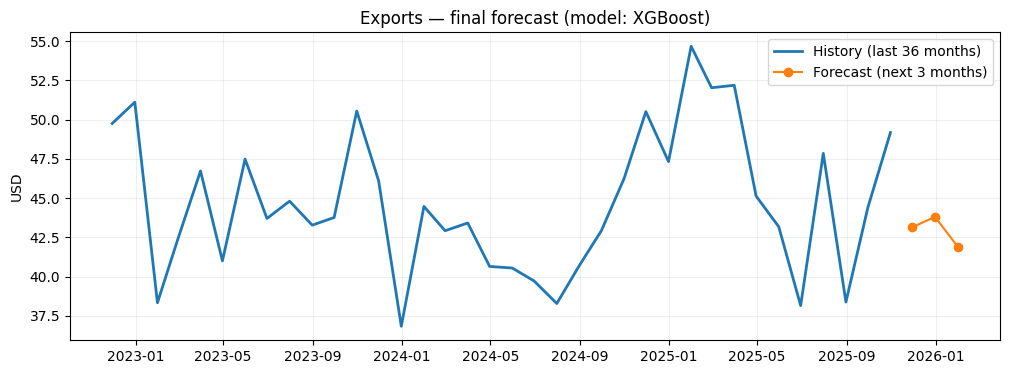

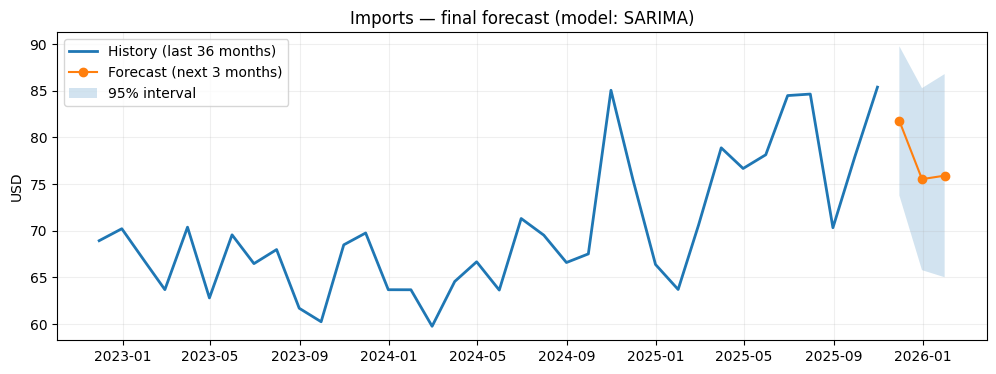


Saved files:
  final_next_3_months_forecast.csv
  final_forecast_summary.csv


In [19]:
# 9A) Safety checks (best model names should exist from Step 8)
if "best_model_exports" not in globals():
    best_model_exports = summary_exports.index[0]
if "best_model_imports" not in globals():
    best_model_imports = summary_imports.index[0]

print("Best model (exports):", best_model_exports)
print("Best model (imports):", best_model_imports)


# 9B) Forecast helpers (with optional prediction intervals)

def forecast_with_intervals(train, model_name, horizon=3, alpha=0.05, ets_boot=500):
    """
    Returns:
      fc (Series), lower (Series or None), upper (Series or None)
    Notes:
      - SARIMA: uses statsmodels get_forecast() => proper model-based CI
      - ETS: uses residual bootstrap PI (good practical approximation)
      - SeasonalNaive/XGBoost: no standard CI here (we return None)
    """
    if model_name == "SeasonalNaive":
        fc = forecast_seasonal_naive(train, horizon=horizon)
        return fc, None, None

    if model_name == "ETS":
        model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12)
        fit = model.fit(optimized=True)
        fc = fit.forecast(horizon)
        fc.name = "ETS"

        # bootstrap prediction intervals using in-sample residuals
        resid = (train - fit.fittedvalues).dropna()
        if len(resid) < 24:
            # if series is short, intervals become unreliable; return none
            return fc, None, None

        sims = []
        for _ in range(ets_boot):
            noise = np.random.choice(resid.values, size=horizon, replace=True)
            sims.append(fc.values + noise)
        sims = np.vstack(sims)

        lower = np.quantile(sims, alpha/2, axis=0)
        upper = np.quantile(sims, 1 - alpha/2, axis=0)

        lower = pd.Series(lower, index=fc.index, name="lower")
        upper = pd.Series(upper, index=fc.index, name="upper")
        return fc, lower, upper

    if model_name == "SARIMA":
        # fit best SARIMA using the same candidate logic from Step 7
        fit, cfg, aic = fit_best_sarima(train)

        pred_res = fit.get_forecast(steps=horizon)
        fc = pred_res.predicted_mean
        fc.name = f"SARIMA{cfg[0]}{cfg[1]}"

        ci = pred_res.conf_int(alpha=alpha)
        lower = ci.iloc[:, 0]
        upper = ci.iloc[:, 1]
        lower.name, upper.name = "lower", "upper"
        return fc, lower, upper

    if model_name == "XGBoost":
        fc = forecast_xgb(train, horizon=horizon)
        return fc, None, None

    raise ValueError("Unknown model_name: " + str(model_name))


def quarter_total_from_forecast(fc):
    # next-3-month total (your quarter horizon)
    return float(np.sum(fc.values))


def plot_final(series, fc, lower=None, upper=None, title=""):
    recent = series.iloc[-36:]  # show last 3 years for context
    plt.figure(figsize=(12,4))
    plt.plot(recent.index, recent.values, label="History (last 36 months)", linewidth=2)
    plt.plot(fc.index, fc.values, marker="o", label="Forecast (next 3 months)")

    if lower is not None and upper is not None:
        plt.fill_between(fc.index, lower.values, upper.values, alpha=0.2, label="95% interval")

    plt.title(title)
    plt.ylabel("USD")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()


# 9C) Forecast exports and imports (full data)
fc_exp, lo_exp, hi_exp = forecast_with_intervals(exports, best_model_exports, horizon=HORIZON)
fc_imp, lo_imp, hi_imp = forecast_with_intervals(imports, best_model_imports, horizon=HORIZON)

q_exp = quarter_total_from_forecast(fc_exp)
q_imp = quarter_total_from_forecast(fc_imp)

# show forecast tables
print("\nExports forecast (next 3 months):")
display(pd.DataFrame({
    "exports_forecast": fc_exp,
    "lower": lo_exp if lo_exp is not None else np.nan,
    "upper": hi_exp if hi_exp is not None else np.nan
}))

print("Exports 3-month total (quarter horizon):", q_exp)

print("\nImports forecast (next 3 months):")
display(pd.DataFrame({
    "imports_forecast": fc_imp,
    "lower": lo_imp if lo_imp is not None else np.nan,
    "upper": hi_imp if hi_imp is not None else np.nan
}))

print("Imports 3-month total (quarter horizon):", q_imp)


# 9D) Plots (presentation-ready)
plot_final(exports, fc_exp, lo_exp, hi_exp, title=f"Exports — final forecast (model: {best_model_exports})")
plot_final(imports, fc_imp, lo_imp, hi_imp, title=f"Imports — final forecast (model: {best_model_imports})")


# 9E) Save outputs for report
final_monthly = pd.DataFrame({
    "exports_forecast": fc_exp,
    "exports_lower": lo_exp if lo_exp is not None else np.nan,
    "exports_upper": hi_exp if hi_exp is not None else np.nan,
    "imports_forecast": fc_imp,
    "imports_lower": lo_imp if lo_imp is not None else np.nan,
    "imports_upper": hi_imp if hi_imp is not None else np.nan,
})

final_summary = pd.DataFrame([{
    "best_model_exports": best_model_exports,
    "best_model_imports": best_model_imports,
    "exports_quarter_total_3m": q_exp,
    "imports_quarter_total_3m": q_imp
}])

final_monthly.to_csv("final_next_3_months_forecast.csv")
final_summary.to_csv("final_forecast_summary.csv", index=False)

print("\nSaved files:")
print("  final_next_3_months_forecast.csv")
print("  final_forecast_summary.csv")


# STEP 10: Visual comparison of model performance and shock analysis

# What you get from this step:
# 1) Quarter totals: actual vs predicted (best model vs baseline)
# 2) Error distributions (boxplots) for monthly metrics + quarterly error
# 3) Shock-window analysis (how models behave during turbulent periods)
# 4) Saves clean tables for your report

Best model (exports): XGBoost
Best model (imports): SARIMA


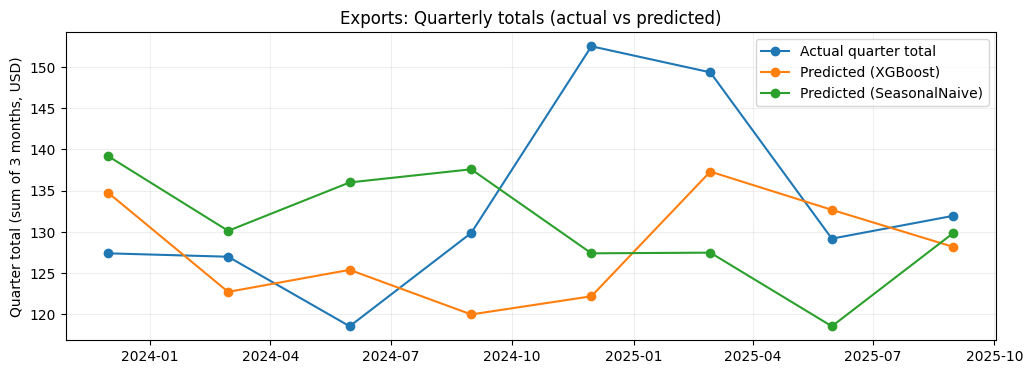

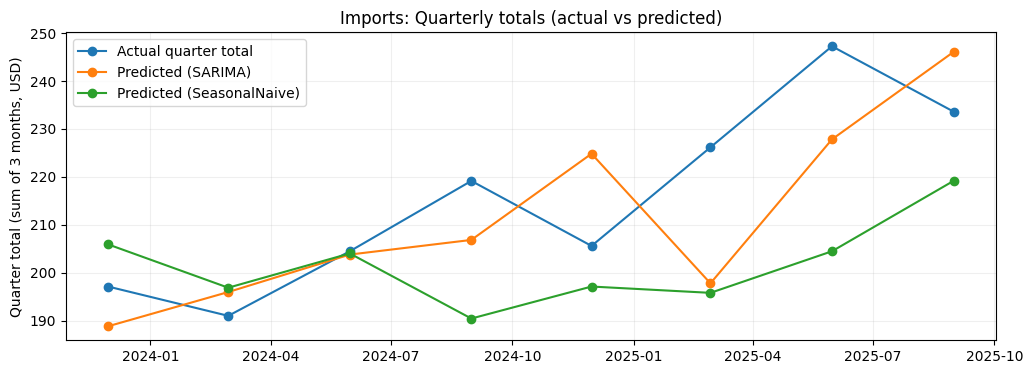

/tmp/ipykernel_191/2189823925.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


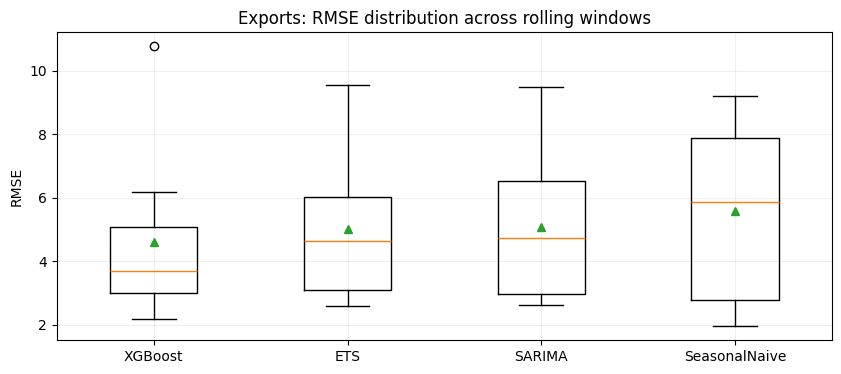

/tmp/ipykernel_191/2189823925.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


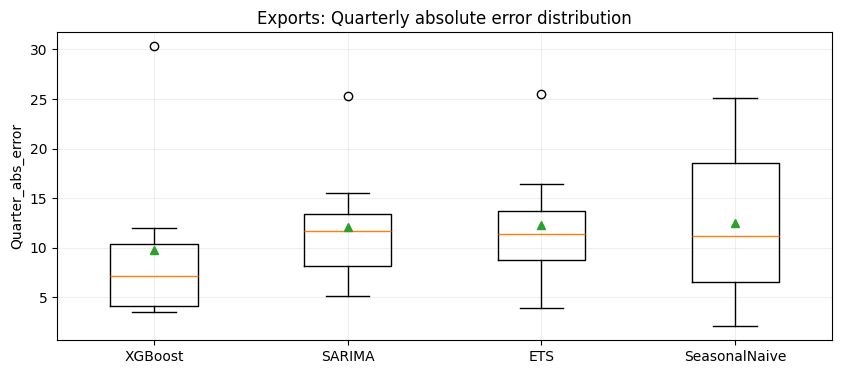

/tmp/ipykernel_191/2189823925.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


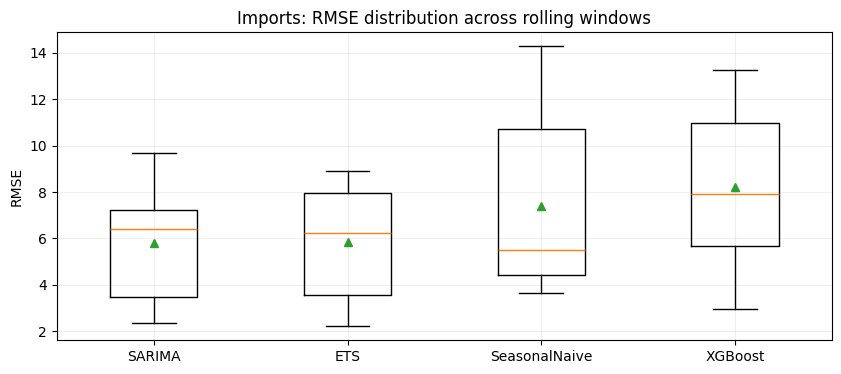

/tmp/ipykernel_191/2189823925.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


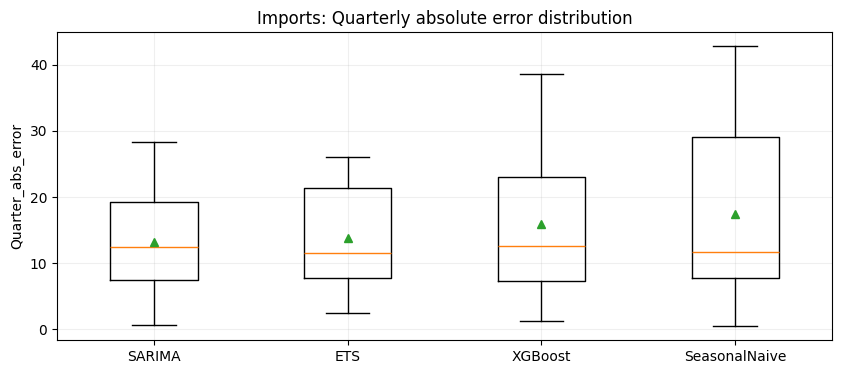


 Exports: average performance in shock vs non-shock windows


,model,is_shock_window,RMSE,MAE,sMAPE_%,Quarter_abs_error
6,XGBoost,False,4.782042,4.225948,9.555144,10.640967
2,SARIMA,False,4.865613,4.166543,9.348657,11.647988
0,ETS,False,4.758588,4.112896,9.242590,11.670604
4,SeasonalNaive,False,5.539157,5.103143,11.395356,12.738000
7,XGBoost,True,3.227446,3.156960,7.334961,3.494709
5,SeasonalNaive,True,5.796341,4.585333,10.833165,10.626000
3,SARIMA,True,6.451572,5.188444,11.763277,15.565332
1,ETS,True,6.792859,5.482161,12.364262,16.446484



 Imports: average performance in shock vs non-shock windows


,model,is_shock_window,RMSE,MAE,sMAPE_%,Quarter_abs_error
2,SARIMA,False,5.474185,5.158285,7.196688,13.345242
0,ETS,False,5.574347,5.228924,7.253371,14.364874
6,XGBoost,False,7.748052,6.891154,9.638903,15.149554
4,SeasonalNaive,False,6.902238,6.305381,8.896861,15.884143
1,ETS,True,7.702389,5.465652,7.154976,9.379569
3,SARIMA,True,8.282946,5.768241,7.592385,12.312746
7,XGBoost,True,11.539256,8.141791,11.098145,20.797288
5,SeasonalNaive,True,10.813069,9.571667,13.523034,28.715000



Exports model summary (means):


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,sMAPE_%_mean,sMAPE_%_std,Quarter_abs_error_mean,Quarter_abs_error_std,RMSE_mean_improve_vs_baseline_%,MAE_mean_improve_vs_baseline_%,sMAPE_%_mean_improve_vs_baseline_%,Quarter_abs_error_mean_improve_vs_baseline_%
model,,,,,,,,,,,,
XGBoost,4.092325,2.576812,4.587718,2.811488,9.277621,5.439237,9.747685,8.842342,17.654526,18.777561,18.078992,21.855984
ETS,4.284054,2.002286,5.012872,2.341819,9.632799,4.173801,12.267589,6.512587,10.023380,14.972214,14.942786,1.654727
SARIMA,4.294280,2.032953,5.063858,2.403242,9.650484,4.256137,12.137656,6.363930,9.108233,14.769248,14.786626,2.696357
SeasonalNaive,5.038417,2.750334,5.571305,2.891860,11.325082,6.062988,12.474000,8.401411,0.000000,0.000000,0.000000,0.000000



Imports model summary (means):


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,sMAPE_%_mean,sMAPE_%_std,Quarter_abs_error_mean,Quarter_abs_error_std,RMSE_mean_improve_vs_baseline_%,MAE_mean_improve_vs_baseline_%,sMAPE_%_mean_improve_vs_baseline_%,Quarter_abs_error_mean_improve_vs_baseline_%
model,,,,,,,,,,,,
SARIMA,5.234530,2.365061,5.825280,2.625713,7.246150,3.157273,13.216180,8.905351,21.185121,22.031732,23.524554,24.427150
ETS,5.258515,2.414764,5.840352,2.694351,7.241072,3.241787,13.741711,8.809006,20.981205,21.674466,23.578149,21.422057
SeasonalNaive,6.713667,4.095184,7.391092,3.982200,9.475133,5.386905,17.488000,14.744543,0.000000,0.000000,0.000000,0.000000
XGBoost,7.047484,3.373195,8.221952,3.572649,9.821308,4.285901,15.855520,13.029001,-11.241375,-4.972202,-3.653513,9.334856



Saved files:
  backtest_exports_all_models.csv
  backtest_imports_all_models.csv
  backtest_exports_shock_flagged.csv
  backtest_imports_shock_flagged.csv


In [20]:
# 10A) Basic checks
needed = ["bt_exports_all", "bt_imports_all", "summary_exports", "summary_imports", "best_model_exports", "best_model_imports"]
missing = [x for x in needed if x not in globals()]
if missing:
    raise ValueError("Missing variables from previous steps: " + ", ".join(missing))

print("Best model (exports):", best_model_exports)
print("Best model (imports):", best_model_imports)

# Ensure datetime columns are datetime type
for d in ["train_end", "test_start", "test_end"]:
    bt_exports_all[d] = pd.to_datetime(bt_exports_all[d])
    bt_imports_all[d] = pd.to_datetime(bt_imports_all[d])

# 10B) Helper: plot quarter totals actual vs predicted
def plot_quarter_totals(bt_df, title, best_model, baseline_model="SeasonalNaive"):
    bt_df = bt_df.sort_values("test_start").copy()

    best = bt_df[bt_df["model"] == best_model].sort_values("test_start")
    base = bt_df[bt_df["model"] == baseline_model].sort_values("test_start")

    # actual quarter totals are the same across models for each window; take from best
    x = best["test_start"]
    actual = best["Quarter_true_sum"]

    plt.figure(figsize=(12,4))
    plt.plot(x, actual, marker="o", label="Actual quarter total")

    plt.plot(x, best["Quarter_pred_sum"], marker="o", label=f"Predicted ({best_model})")
    if len(base) == len(best):
        plt.plot(x, base["Quarter_pred_sum"], marker="o", label=f"Predicted ({baseline_model})")

    plt.title(title)
    plt.ylabel("Quarter total (sum of 3 months, USD)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_quarter_totals(
    bt_exports_all,
    title="Exports: Quarterly totals (actual vs predicted)",
    best_model=best_model_exports
)

plot_quarter_totals(
    bt_imports_all,
    title="Imports: Quarterly totals (actual vs predicted)",
    best_model=best_model_imports
)

# 10C) Error distribution plots (boxplots)
# These show stability: not just average performance but spread across windows.

def boxplot_metric(bt_df, metric, title):
    tmp = bt_df[["model", metric]].dropna()
    order = (tmp.groupby("model")[metric].mean().sort_values().index.tolist())
    data = [tmp[tmp["model"] == m][metric].values for m in order]

    plt.figure(figsize=(10,4))
    plt.boxplot(data, labels=order, showmeans=True)
    plt.title(title)
    plt.ylabel(metric)
    plt.grid(True, alpha=0.2)
    plt.show()

boxplot_metric(bt_exports_all, "RMSE", "Exports: RMSE distribution across rolling windows")
boxplot_metric(bt_exports_all, "Quarter_abs_error", "Exports: Quarterly absolute error distribution")

boxplot_metric(bt_imports_all, "RMSE", "Imports: RMSE distribution across rolling windows")
boxplot_metric(bt_imports_all, "Quarter_abs_error", "Imports: Quarterly absolute error distribution")

# 10D) Shock-window analysis
# We flag windows as "shock windows" if the test period overlaps with top shock months.
# This is useful in viva: "How do models behave during shocks?"

def robust_zscore(x):
    x = pd.Series(x).dropna()
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return 0.6745 * (x - med) / mad

def shock_dates_from_series(series, top_k=12):
    pct = series.pct_change() * 100
    rz = robust_zscore(pct)
    tmp = pd.DataFrame({"pct_change": pct, "robust_z": rz}).dropna()
    tmp["abs_robust_z"] = tmp["robust_z"].abs()
    top = tmp.sort_values("abs_robust_z", ascending=False).head(top_k)
    return pd.to_datetime(top.index)

# Use existing shock tables if they exist; else compute from series
if "shocks_exports" in globals() and isinstance(shocks_exports, pd.DataFrame):
    if "date" in shocks_exports.columns:
        shock_exp_dates = pd.to_datetime(shocks_exports["date"]).sort_values().unique()
    else:
        shock_exp_dates = pd.to_datetime(shocks_exports.index).sort_values().unique()
else:
    shock_exp_dates = shock_dates_from_series(exports, top_k=12).to_numpy()

if "shocks_imports" in globals() and isinstance(shocks_imports, pd.DataFrame):
    if "date" in shocks_imports.columns:
        shock_imp_dates = pd.to_datetime(shocks_imports["date"]).sort_values().unique()
    else:
        shock_imp_dates = pd.to_datetime(shocks_imports.index).sort_values().unique()
else:
    shock_imp_dates = shock_dates_from_series(imports, top_k=12).to_numpy()

def flag_shock_windows(bt_df, shock_dates):
    shock_dates = pd.to_datetime(shock_dates)
    def is_shock(row):
        # if any shock date falls inside [test_start, test_end]
        return np.any((shock_dates >= row["test_start"]) & (shock_dates <= row["test_end"]))
    out = bt_df.copy()
    out["is_shock_window"] = out.apply(is_shock, axis=1)
    return out

bt_exp_flagged = flag_shock_windows(bt_exports_all, shock_exp_dates)
bt_imp_flagged = flag_shock_windows(bt_imports_all, shock_imp_dates)

def shock_summary(bt_df, label):
    # compare average errors in shock vs non-shock windows
    g = (bt_df.groupby(["model", "is_shock_window"])[["RMSE", "MAE", "sMAPE_%", "Quarter_abs_error"]]
         .mean()
         .reset_index()
         .sort_values(["is_shock_window", "Quarter_abs_error"]))
    print("\n", label)
    display(g)

shock_summary(bt_exp_flagged, "Exports: average performance in shock vs non-shock windows")
shock_summary(bt_imp_flagged, "Imports: average performance in shock vs non-shock windows")

# 10E) Clean tables for report
# Summary tables (already computed in Step 8), plus shock-flagged backtest for evidence.
print("\nExports model summary (means):")
display(summary_exports)

print("\nImports model summary (means):")
display(summary_imports)

bt_exports_all.to_csv("backtest_exports_all_models.csv", index=False)
bt_imports_all.to_csv("backtest_imports_all_models.csv", index=False)
bt_exp_flagged.to_csv("backtest_exports_shock_flagged.csv", index=False)
bt_imp_flagged.to_csv("backtest_imports_shock_flagged.csv", index=False)

print("\nSaved files:")
print("  backtest_exports_all_models.csv")
print("  backtest_imports_all_models.csv")
print("  backtest_exports_shock_flagged.csv")
print("  backtest_imports_shock_flagged.csv")


# STEP 11: Preparing final results and outputs for the report

# This step produces:
# 1) Final comparison table: best model vs baseline (exports & imports)
# 2) Next 3 months forecast table
# 3) Next-quarter totals (sum of next 3 months)
# 4) Saves CSV outputs for your report


In [21]:
# 11A) Safety: check required objects
required = ["summary_exports", "summary_imports"]
missing = [x for x in required if x not in globals()]
if missing:
    raise ValueError("Missing: " + ", ".join(missing) + ". Run Step 8 first.")

# Decide which column style we have: old ("RMSE") or new ("RMSE_mean")
def metric_col(summary_df, base_name):
    # base_name examples: "RMSE", "MAE", "sMAPE_%", "Quarter_abs_error"
    if base_name in summary_df.columns:
        return base_name
    if f"{base_name}_mean" in summary_df.columns:
        return f"{base_name}_mean"
    # sometimes summary is a MultiIndex (if not flattened). Handle that too.
    if isinstance(summary_df.columns, pd.MultiIndex):
        if (base_name, "mean") in summary_df.columns:
            return (base_name, "mean")
    raise KeyError(f"Could not find metric column for '{base_name}'. Available columns: {list(summary_df.columns)[:10]} ...")

def get_metric(summary_df, model, base_name):
    col = metric_col(summary_df, base_name)
    return float(summary_df.loc[model, col])

# 11B) Ensure best model names exist
if "best_model_exports" not in globals():
    best_model_exports = summary_exports.index[0]
if "best_model_imports" not in globals():
    best_model_imports = summary_imports.index[0]

baseline_model = "SeasonalNaive"
if baseline_model not in summary_exports.index:
    baseline_model = summary_exports.index[-1]  # fallback (should not happen)
if baseline_model not in summary_imports.index:
    baseline_model = summary_imports.index[-1]

print("Best model (exports):", best_model_exports)
print("Best model (imports):", best_model_imports)
print("Baseline model:", baseline_model)

# 11C) If fc_exp/fc_imp don't exist (Step 9 not run), generate forecasts now
# This keeps Step 11 runnable even if you haven't run Step 9 yet.

def forecast_by_name(train, model_name, horizon=3):
    if model_name == "SeasonalNaive":
        return forecast_seasonal_naive(train, horizon=horizon)
    if model_name == "ETS":
        return forecast_ets(train, horizon=horizon)
    if model_name == "SARIMA":
        return forecast_sarima(train, horizon=horizon)
    if model_name == "XGBoost":
        return forecast_xgb(train, horizon=horizon)
    # If something like "SARIMA(1,1,1)(1,1,1,12)" appears, treat as SARIMA
    if str(model_name).startswith("SARIMA"):
        return forecast_sarima(train, horizon=horizon)
    raise ValueError("Unknown model name: " + str(model_name))

H = globals().get("HORIZON", 3)

if "fc_exp" not in globals():
    fc_exp = forecast_by_name(exports, best_model_exports, horizon=H)
if "fc_imp" not in globals():
    fc_imp = forecast_by_name(imports, best_model_imports, horizon=H)

# 11D) Final comparison table (best vs baseline)
final_table = pd.DataFrame([
    {
        "Series": "Exports",
        "Best_model": best_model_exports,
        "Best_RMSE": get_metric(summary_exports, best_model_exports, "RMSE"),
        "Best_MAE": get_metric(summary_exports, best_model_exports, "MAE"),
        "Best_sMAPE_%": get_metric(summary_exports, best_model_exports, "sMAPE_%"),
        "Best_Quarter_abs_error": get_metric(summary_exports, best_model_exports, "Quarter_abs_error"),
        "Baseline_model": baseline_model,
        "Baseline_RMSE": get_metric(summary_exports, baseline_model, "RMSE"),
        "Baseline_Quarter_abs_error": get_metric(summary_exports, baseline_model, "Quarter_abs_error"),
    },
    {
        "Series": "Imports",
        "Best_model": best_model_imports,
        "Best_RMSE": get_metric(summary_imports, best_model_imports, "RMSE"),
        "Best_MAE": get_metric(summary_imports, best_model_imports, "MAE"),
        "Best_sMAPE_%": get_metric(summary_imports, best_model_imports, "sMAPE_%"),
        "Best_Quarter_abs_error": get_metric(summary_imports, best_model_imports, "Quarter_abs_error"),
        "Baseline_model": baseline_model,
        "Baseline_RMSE": get_metric(summary_imports, baseline_model, "RMSE"),
        "Baseline_Quarter_abs_error": get_metric(summary_imports, baseline_model, "Quarter_abs_error"),
    }
])

print("\nFinal comparison (best vs baseline):")
display(final_table)

# 11E) Next 3 months forecast table + quarter totals
forecast_table = pd.DataFrame({
    "date": fc_exp.index,
    "exports_forecast": fc_exp.values,
    "imports_forecast": fc_imp.values
})

print("\nNext 3 months forecasts:")
display(forecast_table)

exports_next_quarter_total = float(np.sum(fc_exp.values))
imports_next_quarter_total = float(np.sum(fc_imp.values))

print("\nNext-quarter totals (sum of next 3 months):")
print("Exports:", exports_next_quarter_total)
print("Imports:", imports_next_quarter_total)

# 11F) Save outputs for report
final_table.to_csv("final_best_vs_baseline_table.csv", index=False)
forecast_table.to_csv("final_next_3_months_table.csv", index=False)

print("\nSaved files:")
print("  final_best_vs_baseline_table.csv")
print("  final_next_3_months_table.csv")


Best model (exports): XGBoost
Best model (imports): SARIMA
Baseline model: SeasonalNaive

Final comparison (best vs baseline):


,Series,Best_model,Best_RMSE,Best_MAE,Best_sMAPE_%,Best_Quarter_abs_error,Baseline_model,Baseline_RMSE,Baseline_Quarter_abs_error
0,Exports,XGBoost,4.587718,4.092325,9.277621,9.747685,SeasonalNaive,5.571305,12.474
1,Imports,SARIMA,5.825280,5.234530,7.246150,13.216180,SeasonalNaive,7.391092,17.488



Next 3 months forecasts:


,date,exports_forecast,imports_forecast
0,2025-11-30,43.150162,81.763007
1,2025-12-31,43.810970,75.524278
2,2026-01-31,41.919872,75.898175



Next-quarter totals (sum of next 3 months):
Exports: 128.8810043334961
Imports: 233.1854605786575

Saved files:
  final_best_vs_baseline_table.csv
  final_next_3_months_table.csv
